# 1~2장 데이터 다루기

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

fish_data = np.column_stack((fish_length, fish_weight)) #column_stack()는 1차원 배열을 열 방향으로 합쳐서 2차원 배열로 만들어주는 함수입니다.
fish_target = np.concatenate((np.ones(35), np.zeros(14))) #concatenate()는 여러 배열을 하나로 합치는 함수입니다. 여기서는 35개의 1과 14개의 0을 합쳐서 총 49개의 요소를 가진 배열을 만듭니다. 이 배열은 각 데이터 포인트가 어떤 클래스에 속하는지를 나타냅니다. 1은 첫 번째 클래스(예: 특정 종류의 물고기)를 나타내고, 0은 두 번째 클래스(예: 다른 종류의 물고기)를 나타냅니다.

train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42) #train_test_split() 함수는 데이터를 무작위로 섞어서 훈련 세트와 테스트 세트로 나누는 함수입니다. 여기서는 fish_data와 fish_target을 입력으로 받아서 train_input, train_target, test_input, test_target으로 나눕니다. random_state=42는 데이터 분할을 재현 가능하게 하기 위해 사용되는 시드 값입니다. 이 값을 설정하면 같은 데이터를 사용할 때마다 같은 방식으로 데이터를 나눌 수 있습니다.
#print(train_input.shape, test_input.shape) #train_input은 훈련 세트의 입력 데이터이고, test_input은 테스트 세트의 입력 데이터입니다. 각각의 형태는 (훈련 샘플 수, 특성 수)와 (테스트 샘플 수, 특성 수)로 나타납니다.
#print(train_target)
#print(test_target) #1은 도미, 0은 빙어, 이 둘의 비율은 3.3:1 -> 이 비율을 target에 반영하기 위해 stratify 매개변수를 사용하여 데이터를 나눌 때 클래스 비율을 유지하도록 할 수 있습니다. 예를 들어, train_test_split 함수에서 stratify=fish_target을 추가하면 훈련 세트와 테스트 세트 모두에서 도미와 빙어의 비율이 원래 데이터셋과 유사하게 유지됩니다.
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42) 
#print(train_target)
#print(test_target)

#K-Nearest Neighbors(KNN)은 분류와 회귀 문제에 모두 사용할 수 있는 간단한 머신 러닝 알고리즘입니다. KNN은 새로운 데이터 포인트가 주어졌을 때, 훈련 데이터에서 가장 가까운 K개의 이웃을 찾아서 그 이웃들의 클래스 레이블을 기반으로 새로운 데이터 포인트의 클래스를 예측합니다. KNN은 거리 기반 알고리즘이므로, 일반적으로 유클리드 거리나 맨하탄 거리와 같은 거리 측정 방법을 사용하여 이웃을 찾습니다. KNN은 학습 단계가 없고, 예측 단계에서 모든 훈련 데이터를 사용하기 때문에 메모리 사용량이 많고 예측 속도가 느릴 수 있지만, 간단하고 직관적인 모델로 널리 사용됩니다.
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier() #n_neighbors는 가장 가까운 이웃의 수를 지정, return_distance는 이웃과의 거리를 반환할지 여부를 지정. 여기서는 기본값인 n_neighbors=5와 return_distance=True를 사용하여 KNN 모델을 생성
kn.fit(train_input, train_target) #fit() 메서드는 KNN 모델을 훈련 데이터에 맞추는 데 사용됩니다. 여기서는 train_input과 train_target을 입력으로 주어서 모델이 훈련 데이터의 패턴을 학습하도록 합니다. 이 과정에서 KNN은 훈련 데이터의 각 포인트와 그에 해당하는 클래스 레이블을 기억하게 됩니다. 이후에 새로운 데이터 포인트가 주어졌을 때, 모델은 이 훈련 데이터를 기반으로 가장 가까운 이웃을 찾아서 예측을 수행할 수 있습니다.
print(kn.score(test_input, test_target)) #score() 메서드는 모델의 성능을 평가하는 데 사용됩니다. 여기서는 test_input과 test_target을 입력으로 주어서 모델이 테스트 데이터에서 얼마나 정확하게 예측하는지를 계산합니다. 반환되는 값은 0과 1 사이의 숫자로, 1에 가까울수록 모델의 예측이 정확하다는 것을 의미합니다. 예를 들어, 0.9라는 점수가 반환되면 모델이 테스트 데이터에서 90%의 정확도로 예측했다는 것을 나타냅니다.
print(kn.predict([[25, 150]])) #25cm, 150g인 물고기가 도미인지 빙어인지 예측하는 코드입니다. predict() 메서드는 입력된 데이터 포인트가 어떤 클래스에 속하는지를 예측합니다. 여기서는 [[25, 150]]이라는 2차원 배열을 입력으로 주었는데, 이는 길이가 25cm이고 무게가 150g인 물고기를 나타냅니다. 예측 결과는 1이면 도미, 0이면 빙어로 해석할 수 있습니다.

'''
import matplotlib.pyplot as plt
plt.scatter(train_input[:, 0], train_input[:, 1]) #train_input의 첫 번째 열은 길이, 두 번째 열은 무게를 나타냅니다. scatter() 함수는 이 데이터를 시각화하는 데 사용됩니다. 여기서는 train_input의 첫 번째 열을 x축으로, 두 번째 열을 y축으로 하여 산점도를 그립니다. 이렇게 하면 훈련 데이터에서 물고기의 길이와 무게가 어떻게 분포되어 있는지를 시각적으로 확인할 수 있습니다.
plt.scatter(25, 150, marker='^') #25cm, 150g
plt.xlabel('length')
plt.ylabel('weight')
plt.show()
'''

import matplotlib.pyplot as plt
distance, index = kn.kneighbors([[25, 150]]) #kneighbors() 메서드는 입력된 데이터 포인트와 가장 가까운 K개의 이웃을 찾는 데 사용됩니다. 여기서는 [[25, 150]]이라는 2차원 배열을 입력으로 주어서 길이가 25cm이고 무게가 150g인 물고기와 가장 가까운 이웃들을 찾습니다. 반환되는 distance는 입력된 데이터 포인트와 각 이웃 사이의 거리를 나타내는 배열이고, index는 각 이웃의 인덱스를 나타내는 배열입니다. 예를 들어, distance[0]은 첫 번째 이웃과의 거리를 나타내고, index[0]은 첫 번째 이웃의 인덱스를 나타냅니다.
#print(distance) #입력된 데이터 포인트와 가장 가까운 이웃들 사이의 거리를 출력합니다. 이 값은 KNN 알고리즘에서 이웃을 찾는 데 사용되는 거리 측정 방법에 따라 달라질 수 있습니다. 예를 들어, 유클리드 거리를 사용하는 경우, distance 배열에는 입력된 데이터 포인트와 각 이웃 사이의 유클리드 거리가 포함됩니다.
#print(index) #입력된 데이터 포인트와 가장 가까운 이웃들의 인덱스를 출력합니다. 이 인덱스는 훈련 데이터에서 해당 이웃이 위치한 위치를 나타냅니다. 예를 들어, index[0]이 10이라면, 첫 번째 이웃은 훈련 데이터의 10번째 샘플에 해당한다는 것을 의미합니다. 이 인덱스를 사용하여 훈련 데이터에서 해당 이웃의 특성이나 클래스 레이블을 확인할 수 있습니다.
'''
plt.scatter(train_input[:, 0], train_input[:, 1]) #train_input의 첫 번째 열은 길이, 두 번째 열은 무게를 나타냅니다. scatter() 함수는 이 데이터를 시각화하는 데 사용됩니다. 여기서는 train_input의 첫 번째 열을 x축으로, 두 번째 열을 y축으로 하여 산점도를 그립니다. 이렇게 하면 훈련 데이터에서 물고기의 길이와 무게가 어떻게 분포되어 있는지를 시각적으로 확인할 수 있습니다.
plt.scatter(25, 150, marker='^') #25cm, 150g
plt.scatter(train_input[index, 0], train_input[index, 1], marker='D') #index 배열에 있는 이웃들의 위치를 산점도로 표시합니다. 여기서는 index 배열을 사용하여 train_input에서 해당 이웃들의 길이와 무게를 가져와서 x축과 y축으로 사용합니다. marker='D'는 이웃들을 다이아몬드 모양으로 표시하도록 지정하는 옵션입니다. 이렇게 하면 입력된 데이터 포인트와 가장 가까운 이웃들이 시각적으로 구분되어 나타납니다.
plt.xlabel('length')
plt.ylabel('weight')
'''
#plt.show()
#print(train_input[index]) #index 배열에 있는 이웃들의 특성 값을 출력합니다. 여기서는 train_input에서 index 배열에 해당하는 행들을 선택하여 이웃들의 길이와 무게를 출력합니다. 예를 들어, train_input[index]는 index 배열에 있는 이웃들의 길이와 무게를 포함하는 2차원 배열을 반환합니다. 이를 통해 입력된 데이터 포인트와 가장 가까운 이웃들의 특성 값을 확인할 수 있습니다.
mean = np.mean(train_input, axis=0) #train_input의 각 열에 대한 평균을 계산합니다. axis=0은 열 방향으로 평균을 계산하도록 지정하는 옵션입니다. 이렇게 하면 train_input의 첫 번째 열(길이)의 평균과 두 번째 열(무게)의 평균이 각각 계산되어 mean_length 배열에 저장됩니다. 예를 들어, mean_length[0]은 길이의 평균을 나타내고, mean_length[1]은 무게의 평균을 나타냅니다.
std = np.std(train_input, axis=0) #train_input의 각 열에 대한 표준 편차를 계산합니다. axis=0은 열 방향으로 표준 편차를 계산하도록 지정하는 옵션입니다. 이렇게 하면 train_input의 첫 번째 열(길이)의 표준 편차와 두 번째 열(무게)의 표준 편차가 각각 계산되어 std_length 배열에 저장됩니다. 예를 들어, std_length[0]은 길이의 표준 편차를 나타내고, std_length[1]은 무게의 표준 편차를 나타냅니다.
#print(mean, std) #train_input의 각 열에 대한 평균을 출력합니다.
train_scaled = (train_input - mean) / std #train_input의 각 열에서 평균을 빼고 표준 편차로 나누어서 train_scaled 배열을 만듭니다. 이렇게 하면 train_scaled의 각 열은 평균이 0이고 표준 편차가 1인 표준화된 데이터가 됩니다. 예를 들어, train_scaled[:, 0]은 길이의 표준화된 값을 나타내고, train_scaled[:, 1]은 무게의 표준화된 값을 나타냅니다.
test_scaled = (test_input - mean) / std #test_input의 각 열에서 test_input의 평균을 빼고 test_input의 표준 편차로 나누어서 test_scaled 배열을 만듭니다. 이렇게 하면 test_scaled의 각 열도 평균이 0이고 표준 편차가 1인 표준화된 데이터가 됩니다. 예를 들어, test_scaled[:, 0]은 길이의 표준화된 값을 나타내고, test_scaled[:, 1]은 무게의 표준화된 값을 나타냅니다.
kn.fit(train_scaled, train_target) #fit() 메서드는 KNN 모델을 훈련 데이터에 맞추는 데 사용됩니다. 여기서는 train_scaled과 train_target을 입력으로 주어서 모델이 표준화된 훈련 데이터의 패턴을 학습하도록 합니다. 이 과정에서 KNN은 표준화된 훈련 데이터의 각 포인트와 그에 해당하는 클래스 레이블을 기억하게 됩니다. 이후에 새로운 데이터 포인트가 주어졌을 때, 모델은 이 표준화된 훈련 데이터를 기반으로 가장 가까운 이웃을 찾아서 예측을 수행할 수 있습니다.
print(kn.score(test_scaled, test_target)) #score() 메서드는 모델의 성능을 평가합니다. 여기서는 test_scaled과 test_target을 입력으로 주어서 모델이 표준화된 테스트 데이터에서 얼마나 정확하게 예측하는지를 계산합니다. 반환되는 값은 0과 1 사이의 숫자로, 1에 가까울수록 모델의 예측이 정확하다는 것을 의미합니다. 예를 들어, 0.9라는 점수가 반환되면 모델이 표준화된 테스트 데이터에서 90%의 정확도로 예측했다는 것을 나타냅니다.
new = (np.array([[25, 150]]) - mean) / std #새로운 데이터 포인트 [[25, 150]]을 표준화합니다. 여기서는 입력된 데이터 포인트에서 train_input의 평균을 빼고 train_input의 표준 편차로 나누어서 new 배열을 만듭니다. 이렇게 하면 new 배열은 평균이 0이고 표준 편차가 1인 표준화된 데이터가 됩니다. 예를 들어, new[0, 0]은 길이의 표준화된 값을 나타내고, new[0, 1]은 무게의 표준화된 값을 나타냅니다.
print('예측 확률값=', kn.predict(new)) #predict() 메서드는 입력된 데이터 포인트가 어떤 클래스에 속하는지를 예측합니다. 여기서는 new 배열을 입력으로 주어서 길이가 25cm이고 무게가 150g인 물고기가 도미인지 빙어인지 예측합니다. 예측 결과는 1이면 도미, 0이면 빙어로 해석할 수 있습니다.
'''
plt.scatter(train_scaled[:, 0], train_scaled[:, 1]) #train_scaled의 첫 번째 열은 표준화된 길이, 두 번째 열은 표준화된 무게를 나타냅니다. scatter() 함수는 이 데이터를 시각화하는 데 사용됩니다. 여기서는 train_scaled의 첫 번째 열을 x축으로, 두 번째 열을 y축으로 하여 산점도를 그립니다. 이렇게 하면 표준화된 훈련 데이터에서 물고기의 길이와 무게가 어떻게 분포되어 있는지를 시각적으로 확인할 수 있습니다.
plt.scatter(new[0, 0], new[0, 1], marker='^') #new 배열의 첫 번째 요소는 표준화된 길이, 두 번째 요소는 표준화된 무게를 나타냅니다. scatter() 함수는 이 데이터를 시각화하는 데 사용됩니다. 여기서는 new[0, 0]을 x축으로, new[0, 1]을 y축으로 하여 산점도를 그립니다. marker='^'는 이 데이터 포인트를 삼각형 모양으로 표시하도록 지정하는 옵션입니다. 이렇게 하면 입력된 데이터 포인트가 표준화된 훈련 데이터에서 어디에 위치하는지를 시각적으로 확인할 수 있습니다.
plt.scatter(train_scaled[index, 0], train_scaled[index, 1], marker='D') #index2 배열에 있는 이웃들의 위치를 산점도로 표시합니다. 여기서는 index2 배열을 사용하여 train_scaled에서 해당 이웃들의 표준화된 길이와 무게를 가져와서 x축과 y축으로 사용합니다. marker='D'는 이웃들을 다이아몬드 모양으로 표시하도록 지정하는 옵션입니다. 이렇게 하면 입력된 데이터 포인트와 가장 가까운 이웃들이 시각적으로 구분되어 나타납니다.
plt.xlabel('length')
plt.ylabel('weight')
plt.show()
'''

1.0
[0.]
1.0
예측 확률값= [1.]


"\nplt.scatter(train_scaled[:, 0], train_scaled[:, 1]) #train_scaled의 첫 번째 열은 표준화된 길이, 두 번째 열은 표준화된 무게를 나타냅니다. scatter() 함수는 이 데이터를 시각화하는 데 사용됩니다. 여기서는 train_scaled의 첫 번째 열을 x축으로, 두 번째 열을 y축으로 하여 산점도를 그립니다. 이렇게 하면 표준화된 훈련 데이터에서 물고기의 길이와 무게가 어떻게 분포되어 있는지를 시각적으로 확인할 수 있습니다.\nplt.scatter(new[0, 0], new[0, 1], marker='^') #new 배열의 첫 번째 요소는 표준화된 길이, 두 번째 요소는 표준화된 무게를 나타냅니다. scatter() 함수는 이 데이터를 시각화하는 데 사용됩니다. 여기서는 new[0, 0]을 x축으로, new[0, 1]을 y축으로 하여 산점도를 그립니다. marker='^'는 이 데이터 포인트를 삼각형 모양으로 표시하도록 지정하는 옵션입니다. 이렇게 하면 입력된 데이터 포인트가 표준화된 훈련 데이터에서 어디에 위치하는지를 시각적으로 확인할 수 있습니다.\nplt.scatter(train_scaled[index, 0], train_scaled[index, 1], marker='D') #index2 배열에 있는 이웃들의 위치를 산점도로 표시합니다. 여기서는 index2 배열을 사용하여 train_scaled에서 해당 이웃들의 표준화된 길이와 무게를 가져와서 x축과 y축으로 사용합니다. marker='D'는 이웃들을 다이아몬드 모양으로 표시하도록 지정하는 옵션입니다. 이렇게 하면 입력된 데이터 포인트와 가장 가까운 이웃들이 시각적으로 구분되어 나타납니다.\nplt.xlabel('length')\nplt.ylabel('weight')\nplt.show()\n"

In [4]:
# 쉬어가는 코너
import calendar
calendar.setfirstweekday(calendar.SUNDAY) 
#print(calendar.calendar(2026))

# 3장 회귀 알고리즘과 모델 규제

In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')    # Matplotlib에서 한글 출력을 위한 설정
plt.rcParams['axes.unicode_minus'] = False # Matplotlib에서 한글 출력을 위한 설정

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])
'''
plt.scatter(perch_length, perch_weight)
plt.xlabel("길이")
plt.ylabel("무게")
plt.title("농어의 특징점")
plt.show()
'''
#농어 길이와 무게 데이터를 훈련세트와 테스트세트로 나눔
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42) #stratify 매개변수

#넘파이의 reshape() 사용 예
#test_array = np.array([1,2,3,4,5,6])
#print(test_array.shape)
#test_array = test_array.reshape((3,2))
#print(test_array.shape)

train_input = train_input.reshape(-1, 1)
#test_input = test_input.reshape(-1, 1)
test_input = np.reshape(test_input, (-1, 1))
#print(train_input.shape, test_input.shape)


from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()
knr.fit(train_input, train_target)
print(f"{knr.score(test_input, test_target):.1%}")

from sklearn.metrics import mean_absolute_error
test_prediction = knr.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print("MSE =", f"{mae:.2f}") #mse가 평균적으로 19.16g 정도 예측값이 타깃값 간의 차이가 있음을 의미함

#훈련 세트를 사용한 예측
train_prediction = knr.predict(train_input)
mae2 = mean_absolute_error(train_target, train_prediction)
print("MSE2 = ", f"{mae2:.2f}")

#이웃의 개수 k를 3으로 줄임
knr.n_neighbors = 3
knr.fit(train_input, train_target)
print("For Train Set: ", knr.score(train_input, train_target))
print("For Test Set: ", knr.score(test_input, test_target))

#이웃의 개수 k를 10으로 늘임
knr.n_neighbors = 10
knr.fit(train_input, train_target)
print("For Train Set: ", knr.score(train_input, train_target))
print("For Test Set: ", knr.score(test_input, test_target))
print(np.arange(5,45))


99.3%
MSE = 19.16
MSE2 =  35.76
For Train Set:  0.9804899950518966
For Test Set:  0.9746459963987609
For Train Set:  0.96164569026043
For Test Set:  0.9737908255822255
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]


#### 선형 회귀(Linear Regression)

a= [39.01714496] b= -709.0186449535477


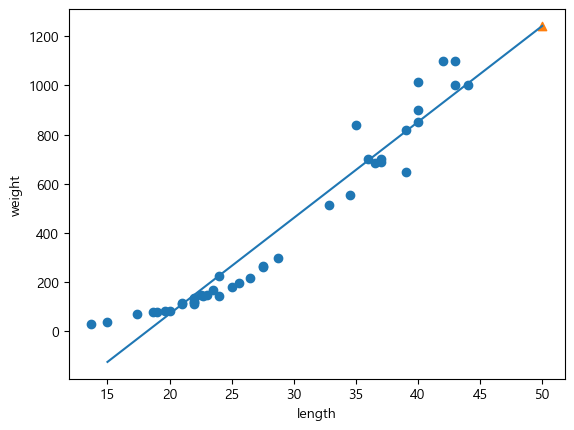

훈련 세트의 평가
0.9398463339976041
테스트 세트의 평가
0.8247503123313559


In [6]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_input, train_target)
#print(lr.predict([[50]])) #input 데이터는 2차원 배열임

print("a=", lr.coef_, "b=", lr.intercept_)

import matplotlib.pyplot as plt
import seaborn as sns
# [필수] 마이너스 기호가 깨지는 현상 방지 설정
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

plt.scatter(train_input, train_target) #target은 weight를 의미함
plt.plot([15,50],[15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_])
plt.scatter(50, 1241.8, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

#훈련 세트와 테스트 세트의 평가
print("훈련 세트의 평가")
print(lr.score(train_input, train_target))
print("테스트 세트의 평가")
print(lr.score(test_input, test_target))

#### 다항 회귀
* 두 데이터 간의 관계를 곡선 형태로 모델링하는 회귀 알고리즘

* $y=ax^2 + bx + c$

[1573.98423528]
[  1.01433211 -21.55792498] 116.0502107827827


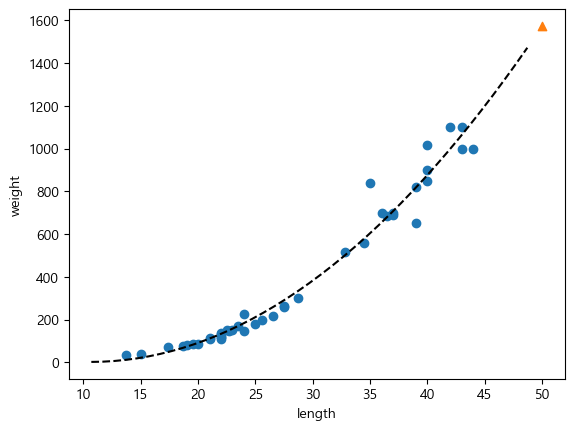

훈련세트 스코어:  0.9706807451768623
테스트세트 스코어:  0.9775935108325122


In [7]:
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))
#print(train_poly.shape, test_poly.shape)
#print(train_poly[:5, :], test_poly[:5, :])

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.predict([[50**2, 50]]))
print(lr.coef_, lr.intercept_)

point = np.arange(np.min(train_input)-3, np.max(train_input)+5)
plt.scatter(train_input, train_target)
plt.plot(point, lr.coef_[0]*point**2+lr.coef_[1]*point+lr.intercept_, linestyle="dashed", color="black")
#plt.plot(point, 1.01*point**2-21.6*point+116.05)
plt.scatter(50, 1574, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()
print("훈련세트 스코어: ", lr.score(train_poly, train_target))
print("테스트세트 스코어: ", lr.score(test_poly, test_target))

#### 다중 회귀
* Pandas의 DataFrame을 입력데이터로 직접 사용
- Pandas를 사용하면 인터넷에서 CSV파일을 내려받아 데이터프레임으로 저장할 수 있음
- 데이터프레임은 to_numpy() 메소드로 넘파이 배열로 변환함

In [8]:
#Jupyter Notebook에서 사이킷런과 판다스 버전을 확인하는 명령
!pip show scikit-learn pandas

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\yccho\miniconda3\envs\room311\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 
---
Name: pandas
Version: 3.0.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

 Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
 All rights reserved.

 Copyright (c) 2011-2026, Open source contributors.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of cond

In [9]:
import pandas as pd
perch_full = pd.read_csv('perch_full.csv')
print(perch_full.shape)
print(type(perch_full))
perch_full.head()

#perch_full과 perch_weight를 훈련 세트와 테스트 세트로 나눔
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)
#print(train_input.shape) : 열이 3개임(length, height, width) 즉 3개의 특성임
#print(train_target.shape) : 무게값만 갖는 1열이 1개인 2차원 배열

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(include_bias=False)
#poly.fit([[2, 3]])
#print(poly.transform([[2, 3]]))
poly.fit(train_input)
train_poly=poly.transform(train_input)
#print(train_poly.shape) #3개의 특성으로 새로 생성한 특성은 총 9개가 됨(열수가 9가 되며 행수는 변함없음)
#print(poly.get_feature_names_out())
test_poly=poly.transform(test_input)

(56, 3)
<class 'pandas.DataFrame'>


In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9903183436982126
0.9714559911594095


In [11]:
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
test_poly=poly.transform(test_input) #overfitting
print(lr.score(test_poly, test_target)) #Regularization이 필요함

0.9999999999976599
-144.4072001577299


##### 규제(Regularization)
* 모델이 훈련 세트에 overfitting되지 않도록 특성 수를 제한하는 것
* 규제를 적용하기 전에 특성에 대해 정규화를 시행해야 함

In [12]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
print(train_poly.shape)
#print("mean=", ss.mean_, "STD=", ss.scale_)
#print(ss.mean_.shape) #(55,)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

(42, 55)


##### 릿지 회귀 모델(Ridge Linear Regression)
* 규제를 적용한 회귀 모델
* 계수를 제곱한 값을 기준으로 규제를 적용함

In [13]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9896101671037343
0.9790693977615382


* Ridge 모델에서 alpha값에 따른 score값의 변화 그래프

Text(0, 0.5, 'score')

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

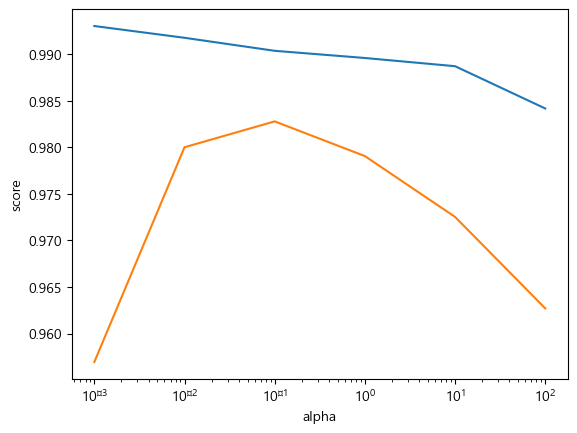

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
# [필수] 마이너스 기호가 깨지는 현상 방지 설정
plt.rcParams['axes.unicode_minus'] = False

train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('score') #score() 값은 결정 계수임 --> 최적의 alpha는 0.1일 때임

In [15]:
#사전에 훈련 세트와 테스트 세트는 모두 정규화됨(StandardScaler 사용)
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570368
0.9827976465386865


##### 라쏘 회귀 모델(Lasso Linear Regression)
* 규제를 적용한 회귀 모델
* 계수를 제곱한 값을 기준으로 규제를 적용함

In [16]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))

0.989789897208096


* Lasso 모델에서 alpha값에 따른 score값의 변화 그래프

c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a 

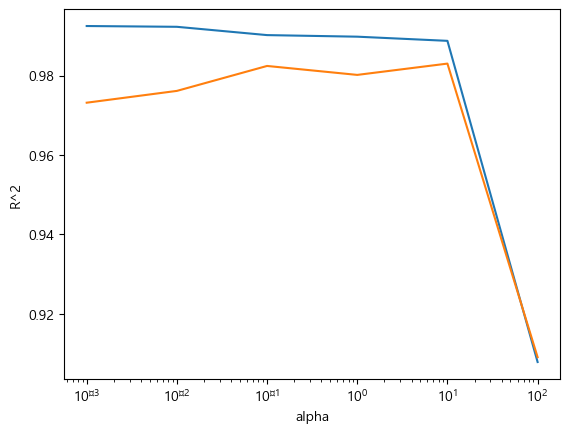

In [17]:
import matplotlib.pyplot as plt
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

* 최적의 alpha값(10)을 사용한 라쏘 회귀 모델 결과

In [18]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

#Lasso 모델을 계수를 0으로 만들 수 있음
print(np.sum(lasso.coef_==0))

0.9888067471131866
0.9824470598706695
40


## 4장 다양한 분류 알고리즘
1. 로지스틱 회귀
2. 확률적 경사 하강법

##### (1)로지스틱 회귀

In [19]:
import pandas as pd
fish = pd.read_csv("fish.csv")
fish.head()

#Species 열에 있는 값(중복 제거)을 표시함
print(pd.unique(fish['Species']))

#Species열은 타깃으로 사용, 나머지 5개 열은 입력으로 사용함
fish_target = fish['Species']
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']] #열 이름을 리스트로 묶어 전달해야 함
print(fish_input.shape)
print(fish_target.shape)
#fish_input.head()

#훈련세트와 테스트세트로 나눔: 머신러닝에서는 기본적으로 2개의 세트가 필요함
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

#정규화
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#k-최근접 이웃 분류기의 확률 예측
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

print(kn.classes_) #저장된 타깃값을 출력함
#테스트 세트의 처음 5개 입력에 대한 예측 결과
#print(kn.predict(test_scaled[:5]))

#예측 결과에 대한 확률 출력: 각 입력에 대해 7개 타깃값에 대한 확률을 출력함
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
#print(np.round(proba, decimals=4)) #소수점 4째 자리까지 출력

#테스트 세트에서 4번 입력값에 대한 최근접 이웃(3개)을 확인함
distance, indexes = kn.kneighbors(test_scaled[3:4]) #test_scaled[3]이 아니라 슬라이싱으로 지정해야 함(2차원 배열)
print(indexes[0]) #최근접 이웃(3개)들의 인덱스가 저장
print(train_target.iloc[indexes[0]]) #이 인덱스로 타깃 세트에서 이 최근접 이웃의 Species를 출력함


<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str
(159, 5)
(159,)
0.8907563025210085
0.85
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[104 115 106]
52     Roach
106    Perch
103    Perch
Name: Species, dtype: str


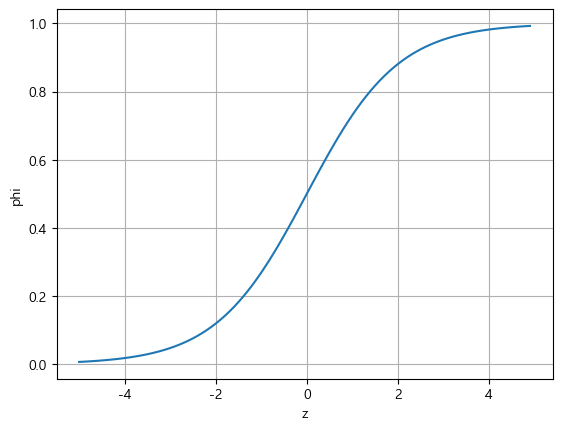

In [20]:
#numpy를 사용한 로지스틱 함수(시그모이드 함수) 출력
import numpy as np
import matplotlib.pyplot as plt
z = np.arange(-5, 5, 0.1)
phi = 1/(1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.grid(True)
plt.show()

In [21]:
#넘파이의 불리언 인덱싱 테스트: 인덱스 대신에 True, False값의 리스트를 넘겨주면 True에 해당하는 값만 선택됨
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
char_arr[[True, False, True, False, False]]

array(['A', 'C'], dtype='<U1')

##### 이진 분류

In [22]:
#훈련 세트에서 도미(Bream)과 빙어(Smelt) 행만 골라냄
#train_target의 shape은 (119,)
#훈련 세트의 타깃에서 Bream과 Smelt의 True, False 리스트(불리언 인덱싱용)를 추출하여 훈련 세트와 타깃 세트를 새로 만듦
bream_smelt_indexes = (train_target=="Bream") | (train_target=="Smelt")
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

#이를 사용하여 훈련함
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

#print(lr.predict(train_bream_smelt[:5]))
#print(target_bream_smelt[:5])
print(lr.predict_proba(train_bream_smelt[:5]))
print(lr.classes_)
print(lr.coef_, lr.intercept_)
#decision_function()으로 z값을 출력할 수 있음(5개 샘플의 z값 출력)
decision = lr.decision_function(train_bream_smelt[:5])
print(decision)

#z값에 대한 확률(시그모이드 값 출력): scipy 모듈의 expit 함수 사용
from scipy.special import expit
print(expit(decision))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]
['Bream' 'Smelt']
[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]
[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]
[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


##### 다중 분류
* 타깃 클래스인 생선 데이터의 수는 7개

In [23]:
lr = LogisticRegression(C=20, max_iter=1000) #C는 규제 제어변수, 기본값은 1이며 작을수록 규제가 강함
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

#테스트 세트에서 5개 샘플에 대한 예측 결과
print(lr.predict(test_scaled[:5]))
print(test_target[:5])

#테스트 세트에서 5개 샘플에 대한 예측 확률
proba = lr.predict_proba(test_scaled[:5])
print(lr.classes_) #타킷 세트의 클래스 분류 출력
print(np.round(proba, decimals=3))

#계수(가중치)의 shape 출력
print(lr.coef_.shape, lr.intercept_.shape)

#5개의 샘플에 대해 z값을 구함 -> 샘플당 z값은 7개의 타깃 클래스에 대해 구해짐(z1, z2, ..., z7)
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=3))

#5개 샘플의 z값(z1, z2, ..., z7)에 대해 확률 계산(소프트맥스 함수 사용)
from scipy.special import softmax
proba = softmax(decision, axis=1) #axis=1은 각 행(각 샘플)에 대해 구함
print(np.round(proba, decimals=3))

0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
78         Perch
155        Smelt
128         Pike
55     Whitefish
94         Perch
Name: Species, dtype: str
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]
(7, 5) (7,)
[[ -6.507   1.039   5.168  -2.757   3.337   0.346  -0.625]
 [-10.879   1.944   4.776  -2.423   2.987   7.842  -4.247]
 [ -4.338  -6.237   3.167   6.481   2.364   2.434  -3.872]
 [ -0.691   0.446   2.643  -1.215   3.261  -5.701   1.257]
 [ -6.401  -1.991   5.815  -0.135   3.499  -0.088  -0.699]]
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


##### (2)확률적 경사 하강법
- 훈련 데이터가 한 번에 준비되는 것이 아니라 조금씩 전달되는 상황
- 기존의 훈련 데이터에 새로운 데이터를 추가하여 훈련함(단점: 시간이 지날수록 데이터양이 크게 늘어남)
- 새로운 데이터를 추가할 때 기존의 데이터 일부를 버려 훈련 데이터의 크기를 일정하게 유지함(단점: 중요한 데이터가 버려질 수 있음)

> 점진적 학습(온라인 학습): 이미 훈련한 모델을 버리지 않고 새로운 데이터에 대해서만 조금씩 더 훈련함
- 대표적인 알고리즘: 확률적 경사 하강법(Stochastic Gradient Descent)


In [24]:
#판다스로 데이터 읽어오기
import pandas as pd
fish = pd.read_csv("fish.csv")

#Species열은 타깃 데이터로, 나머지는 입력 데이터로 사용함
fish_input = fish[["Weight", "Length", "Diagonal", "Height", "Width"]]
fish_target = fish["Species"]

#훈련 세트와 테스트 세트로 나눔
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

#훈련 세트와 테스트 세트를 정규화함(사용하는 평균과 표준편차는 훈련 세트에서 구함)
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#SGDClassifier 사용
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss="log_loss", max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

#점진적 학습
sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7815126050420168
0.8
0.8067226890756303
0.825


c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


* 확률적 경사 하강법에서 과대적합 직전의 에포크 값 구하기
  - epoch를 300회까지 증가하면서 정확도(score) 추이를 확인함


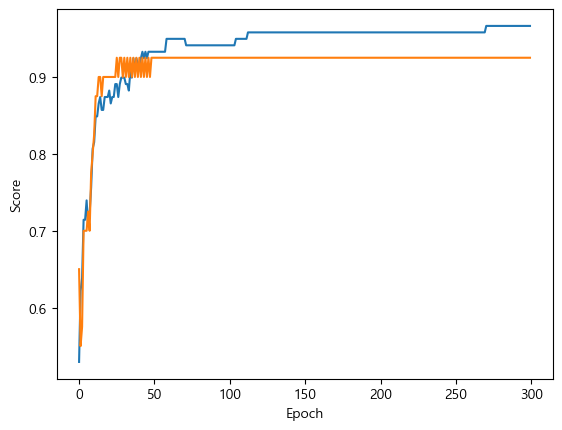

In [25]:
import numpy as np
sc = SGDClassifier(loss="log_loss", random_state=42) #max_iter의 기본값은 1000임
train_score = []
test_score = []
classes = np.unique(train_target)

for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes=classes) #partial_fit()에서는 max_iter은 무시하고 1-epoch만 함
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.show()

* epoch가 100일 때부터 과대적합이 시작됨
     - max_iter을 100으로 설정하여 학습을 진행함

In [26]:
#SGDClassifier의 max_iter 매개변수값 수정
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss="log_loss", max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [27]:
#hinge 손실 함수를 사용한 확률적 경사 하강법
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss="hinge", max_iter=100, tol=None, random_state=42) #hinge는 loss 매개변수의 기본값임
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925


## 5장 트리 알고리즘
1. 결정 트리
2. 교차 검증과 그리드 서치
3. 트리의 앙상블

##### (1)결정 트리
* 와인 캔의 알코올 도수, 당도, pH값으로 와인의 종류를 구별하는 문제 -> 로지스틱 회귀 모델


In [28]:
#와인 샘플 데이터: https://bit.ly/wine_csv_data
import pandas as pd
wine = pd.read_csv("wine.csv") #샘플 데이터 수는 6,497개
wine.head() 


,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [29]:
#Pandas의 유용한 메소드: info(), describe()
wine.info() #DataFrame의 각 열의 데이터 타입과 누락된 데이터가 있는지 확인
wine.describe() #열에 대한 통계(최소, 최대, 평균값 등)를 출력

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [30]:
#전체 데이터에서 입력 데이터와 타깃 데이터를 추출함
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

#입력 데이터와 타깃 데이터를 훈련 세트와 테스트 세트로 나눔
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42) #test_size를 지정하지 않으면 25%를 지정함. 여기서는 20%만 지정하도록 함
#print(train_input.shape, test_input.shape) #->(5197, 3) (1300, 3)

#입력 데이터의 정규화(DataFrame이 넘파이 배열로 반환됨)
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input) #DataFrame이 넘파이 배열로 반환됨
test_scaled = ss.transform(test_input)

#로지스틱 회귀 모델을 사용한 학습
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


##### 결정 트리

0.996921300750433
0.8592307692307692


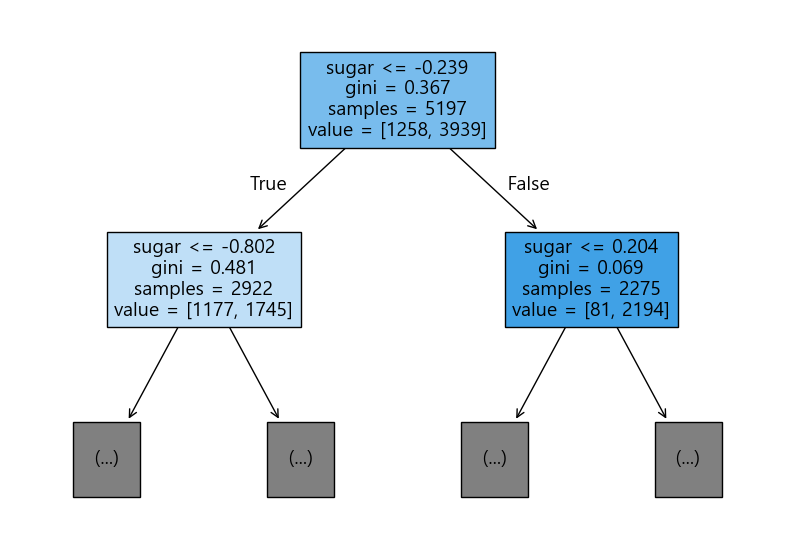

In [31]:
#결정 트리 알고리즘 적용
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42) #random_state는 기존 결과와 같은 맥락을 유지하기 위해 사용한 것이며, 실전에서는 필요치 않음
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

#dt의 tree 출력
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,7))
#plot_tree(dt)
#plt.show()

#결정 트리에서 노드를 1단계만 출력, 색상 지정, 특성 이름 출력으로 설정
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

0.8454877814123533
0.8415384615384616


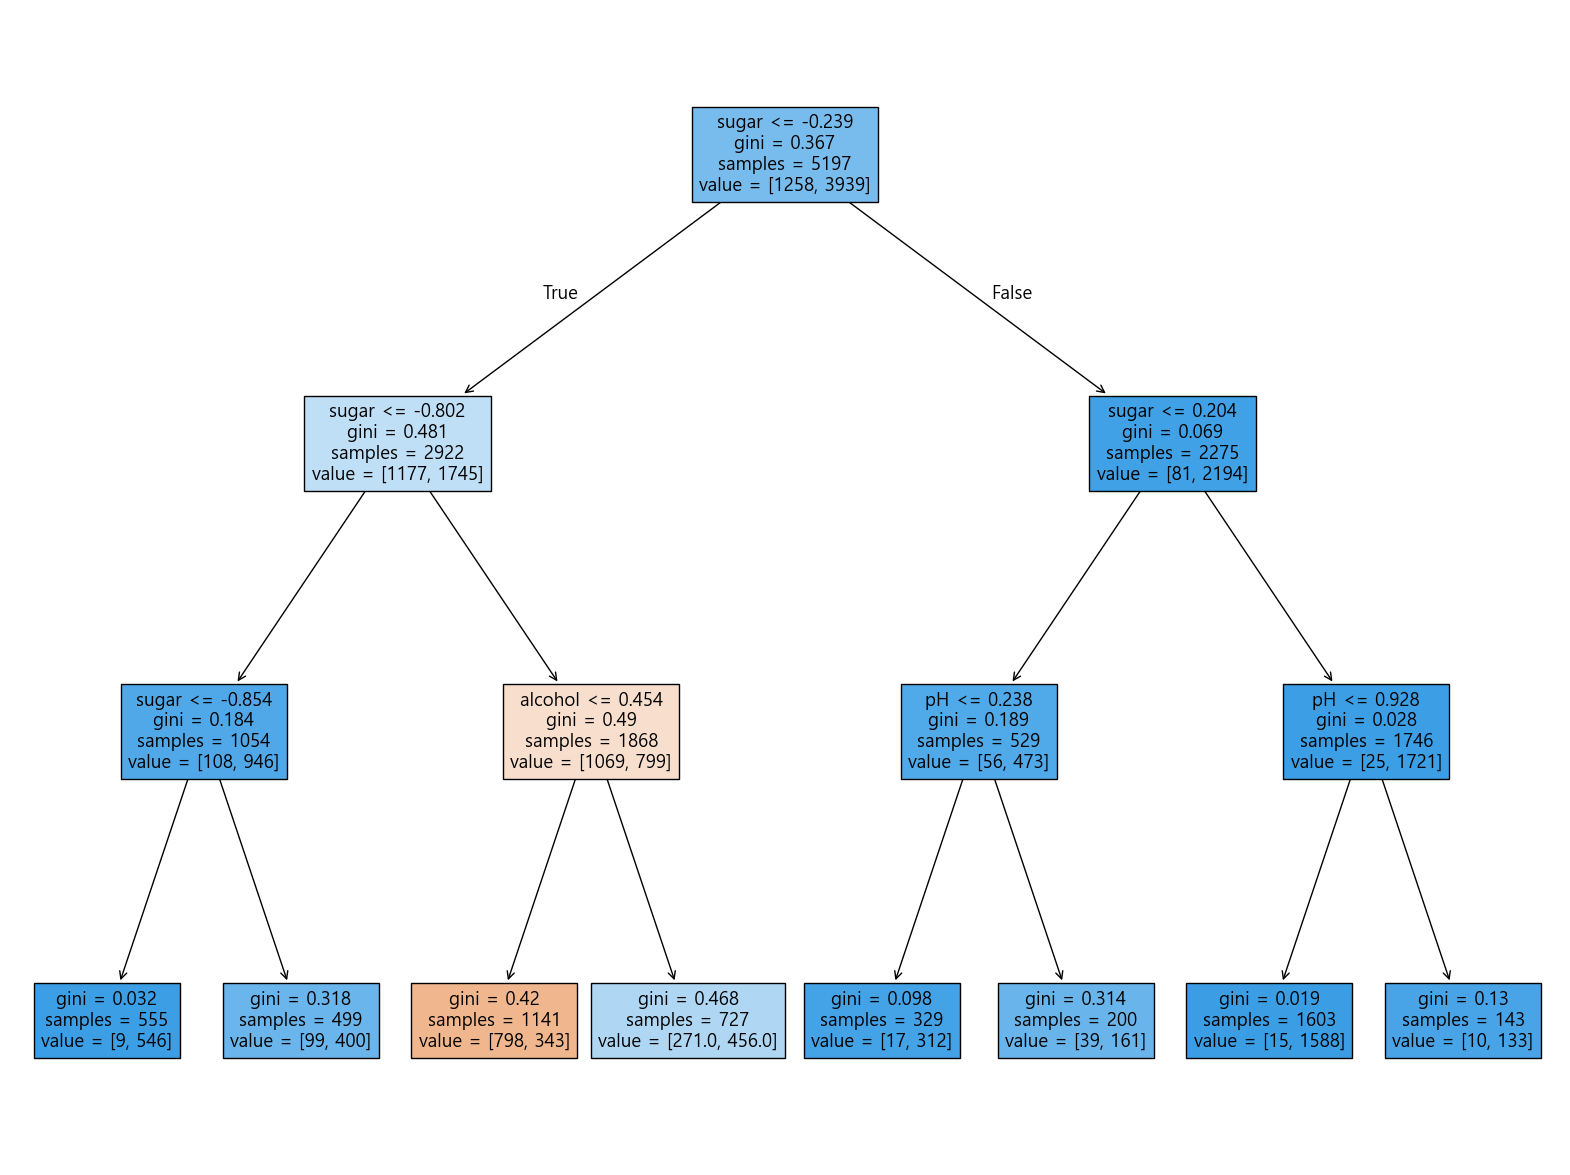

[0.12345626 0.86862934 0.0079144 ]


In [32]:
#사전 가지치기로 최대 깊이를 3으로 설정
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

#트리 그리기
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

#특성 중요도: 트리에서 특성별로 사용되는 정도(정보이득x(현재 노드 데이터/전체 노드 데이터)를 해당 특성이 사용된 노드에 대해 더함)
print(dt.feature_importances_)

##### (2)교차 검증과 그리드 서치
* 검증 세트

In [33]:
#검증 세트 만들기
import pandas as pd
wine = pd.read_csv("wine.csv") #샘플 데이터 수는 6,497개

data = wine[['alcohol', 'sugar', 'pH']] #3개 열을 입력 데이터로 추출함
target = wine['class'] #1개 열을 타깃 데이터로 추출함

#훈련 세트와 테스트 세트로 나눔
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

#훈련 세트를 다시 나눔 -> 검증 세트 20%로 나눔
sub_input, val_input, sub_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

#sub_input, sub_target, val_input, val_target를 사용하여 모델을 만들고 평가함
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)
print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

0.9971133028626413
0.864423076923077


* 교차 검증

In [34]:
#교차 검증(5-폴드 교차 검증)
from sklearn.model_selection import cross_validate
scores = cross_validate(dt, train_input, train_target)
print(scores)

#최종 검증 점수는 반환값에서 test_score키에 대한 값들의 평균으로 정해짐
import numpy as np
print(np.mean(scores['test_score']))

#훈련 세트를 섞고 10-폴드 교차 검증을 수행함: 분할기를 만든 후 cv 매개변수에 지정함
from sklearn.model_selection import StratifiedKFold
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #분할기 생성
scores = cross_validate(dt, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))

{'fit_time': array([0.00747871, 0.00660396, 0.00656891, 0.00657845, 0.00694156]), 'score_time': array([0.003052  , 0.0019815 , 0.0019989 , 0.00199866, 0.0015142 ]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}
0.855300214703487
0.8574181117533719


* 하이퍼 파라미터 튜닝
   - 하나의 파라미터만 사용

In [35]:
#GridSearchCV 모듈 임포트
from sklearn.model_selection import GridSearchCV
#탐색할 매개변수와 탐색할 값들을 딕셔너리로 만듦
params = {'min_impurity_decrease':[0.0001, 0.0002, 0.0003, 0.0004, 0.0005]} 
#객체 생성: DecisionTreeClassifier 객체와 탐색할 params 딕셔너리를 전달함
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1) #n_jobs는 병렬실행에 사용할 CPU 코어수를 지정하며, -1일 때는 모든 코어를 사용하도록 함
#GridSearchCV의 cv매개변수 기본값은 5임(5-폴드 교차 검증)

#gs 객체로 fit()을 실행하여 학습함
gs.fit(train_input, train_target)

#학습 후, 최적의 매개변수로 전체 훈련 세트에 대해 학습하고 학습된 모델을 'best_estimator_'속성에 저장함
dt = gs.best_estimator_
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

#최적의 매개변수 출력
print(gs.best_params_)

#교차 검증의 평균 점수
print(gs.cv_results_['mean_test_score'])

#최적의 파라미터와 값에 대한 인덱스를 사용하여 파라미터를 출력함
print(gs.cv_results_['params'][gs.best_index_])

0.9615162593804117
0.8653846153846154
{'min_impurity_decrease': 0.0001}
[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]
{'min_impurity_decrease': 0.0001}


* 여러 파라미터에 대한 튜닝

In [36]:
import numpy as np
#params 딕셔너리 생성
params = {'min_impurity_decrease':np.arange(0.0001, 0.001, 0.0001), #0.0001에서 0.0001간격으로 0.001까지 배열 생성
          'max_depth':range(5,20,1), #정수만 사용가능하며, 5에서 20까지 1씩 증가하는 배열 생성
          'min_samples_split': range(2,100,10)}

#GridSearchCV 객체 생성
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(train_input, train_target)
print(gs.best_params_)

#최고의 교차 검증 점수 출력: 'mean_test_score'키의 값들 중에서 최대값을 출력함
print(np.max(gs.cv_results_['mean_test_score']))

{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}
0.8683865773302731


* 랜덤 서치
   - 교차 검증에서 매개변수 값의 간격을 일정하게 하지 않고 주어진 범위 내에서 정해진 횟수만큼 랜덤하게 선택해서 사용
   - params 딕셔너리를 만들 때 매개변수 키의 값을 지정할 때 범위를 확률 또는 랜덤값을 정하고 RandomizedSearchCV() 객체 생성 시 n_iter 매개변수로 횟수를 지정하여 사용
   - scipy라이브러리를 함께 사용함

In [37]:
from scipy.stats import uniform, randint
#uniform()은 실수값을, randint()는 정수값을 추출할 때 사용
rgen = randint(0,10) #0~10사이 정수를 추출
rgen.rvs(10) #10개의 샘플을 추출
np.unique(rgen.rvs(1000), return_counts=True)

ugen = uniform(0,1) #0에서 1사이의 실수를 추출
ugen.rvs(10)

#4개의 매개변수에 대해 랜덤 서치할 샘플링 범위를 지정함
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20,50),
          'min_samples_split': randint(2,25),
          'min_samples_leaf': randint(1,25)}

#랜덤 서치를 위한 객체 생성
from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params, n_iter=100, n_jobs=-1, random_state=42)
rs.fit(train_input, train_target)

#최적의 파라미터 값 출력
print(rs.best_params_)

#최고의 교차 검증 점수
print(np.max(rs.cv_results_['mean_test_score']))

#최적의 모델은 전체 훈련 세트(train_input, train_target)로 훈련한 후, best_estimator_ 속성에 저장되어 있음
dt = rs.best_estimator_

#이를 사용하여 테스트 세트를 평가함
print(dt.score(test_input, test_target))

{'max_depth': 39, 'min_impurity_decrease': np.float64(0.00034102546602601173), 'min_samples_leaf': 7, 'min_samples_split': 13}
0.8695428296438884
0.86


##### (3)트리의 앙상블
* 앙상블 학습
    - 랜덤 포레스트
    - 엑스트라 트리
* 그레이디언트 부스팅

In [38]:
#Random Forest를 화이트 와이 분류 문제에 적용함
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
wine = pd.read_csv("wine.csv") #DataFrame
wine.head()
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']
#훈련 세트와 테스트 세트(20%)를 정함
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

#cross_validate()로 교차 검증
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

#랜덤 포레스트의 특성 중요도
rf.fit(train_input, train_target)
print(rf.feature_importances_) #기존의 결정 트리의 특성 중요도와 달리 랜덤하게 선택하여 특성들을 훈련에 사용하기 때문에 과대적합을 줄이고 일반화 성능을 높이게 됨

#OOB(out of bag)샘플을 사용한 RandomForest 모델 검증
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)

rf.fit(train_input, train_target)
print(rf.oob_score_)

0.9973541965122431 0.8905151032797809
[0.23167441 0.50039841 0.26792718]
0.8934000384837406


* 엑스트라 트리(Extra Tree)

In [39]:
#기본적으로 100개의 트리를 학습함
#모듈 임포트와 객체 생성
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']))
print(np.mean(scores['test_score']))

#엑스트라 트리도 특성 중요도를 제공함
et.fit(train_input, train_target)
print(et.feature_importances_)

0.9974503966084433
0.8887848893166506
[0.20183568 0.52242907 0.27573525]


* **Gradient Boosting**

In [40]:
#그레디언트 부스팅을 사용한 교차 검증
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, n_jobs=-1, return_train_score=True)
print(np.mean(scores['train_score']))
print(np.mean(scores['test_score']))

#그레디언트 부스팅의 결정트리를 500개로 늘이고 학습률을 2배로 증가하여 교차 검증함
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42)
scores = cross_validate(gb, train_input, train_target, n_jobs=-1, return_train_score=True)
print('결정트리 수=500(5배 증가), 학습률=0.2(2배 증가)')
print(np.mean(scores['train_score']))
print(np.mean(scores['test_score']))

#그레이언트 부스팅의 특성 중요도
gb.fit(train_input, train_target)
print(gb.feature_importances_)

0.8881086892152563
0.8720430147331015
결정트리 수=500(5배 증가), 학습률=0.2(2배 증가)
0.9464595437171814
0.8780082549788999
[0.15882696 0.6799705  0.16120254]


* **히스토그램 기반 그레디언트 부스팅**

In [41]:
#히스토그램 기반 그레디언트 부스팅
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, n_jobs=-1, return_train_score=True, return_estimator=True)
print(np.mean(scores['train_score']))
print(np.mean(scores['test_score']))
print(scores['estimator'])

#permutation_importance()를 사용한 훈련 세트에 대한 특성 중요도 계산
from sklearn.inspection import permutation_importance
hgb.fit(train_input, train_target) #훈련 세트에 대해 학습함
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

#테스트 세트에 대한 특성 중요도 계산
hgb.fit(test_input, test_target)
result = permutation_importance(hgb, test_input, test_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean, result.importances_std)
#테스트 세트의 성능 점수
print("훈련 세트 성능 점수=", hgb.score(train_input, train_target))
print("테스트 세트 성능 점수=", hgb.score(test_input, test_target))

0.9321723946453317
0.8801241948619236
[HistGradientBoostingClassifier(random_state=42), HistGradientBoostingClassifier(random_state=42), HistGradientBoostingClassifier(random_state=42), HistGradientBoostingClassifier(random_state=42), HistGradientBoostingClassifier(random_state=42)]
[0.08876275 0.23438522 0.08027708]
[0.14092308 0.27415385 0.13746154] [0.00714847 0.00626061 0.00598865]
훈련 세트 성능 점수= 0.8597267654416009
테스트 세트 성능 점수= 0.9730769230769231


* 그레디언트 부스팅 알고리즘을 구현한 라이브러리
    - XGBoost : 사용하려면 conda install -c conda-forge py-xgboost로 설치해야 함
    - LightGBM : conda install -c conda-forge lightgbm

In [42]:
#xgboost로 와인 데이터에 대한 교차 검증
from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print("XBGoost를 사용한 훈련 세트와 테스트 세트의 성능 점수")
print(np.mean(scores['train_score']))
print(np.mean(scores['test_score']))

#lightgbm으로 와이 데이터에 대한 교차 검증
from lightgbm import LGBMClassifier
lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print("LightGBM을 사용한 훈련 세트와 테스트 세트의 성능 점수")
print(np.mean(scores['train_score']))
print(np.mean(scores['test_score']))

XBGoost를 사용한 훈련 세트와 테스트 세트의 성능 점수
0.9567059184812372
0.8783915747390243
LightGBM을 사용한 훈련 세트와 테스트 세트의 성능 점수
0.935828414851749
0.8801251203079884


## 6장 비지도 학습(Unsupervised Learning)
1. 군집 알고리즘
2. k-평균
3. PCA 알고리즘

##### (1)군집 알고리즘
* 흑백 사진을 분류(타깃을 모르는 과일 사진을 종류별로 분류하는 문제)
   - 윈도우 파워셀: curl https://bit.ly/fruits_300_data -o fruits_300.npy

(300, 100, 100)


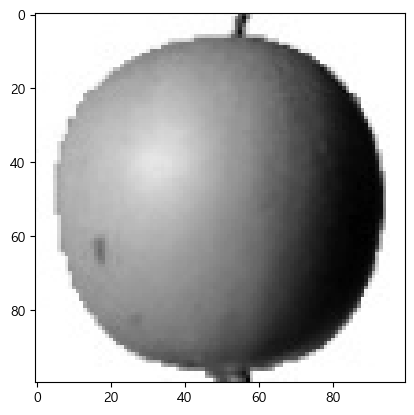

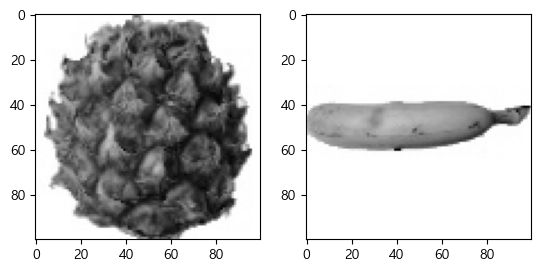

In [46]:
import numpy as np
import matplotlib.pyplot as plt

fruits = np.load('fruits_300.npy') #넘파이 배열로 읽어들이기
print(fruits.shape)

#넘파이 배열 이미지 출력
plt.imshow(fruits[0], cmap='gray_r')
plt.show()

#이미지 2개 출력
fig, axs = plt.subplots(1,2)
axs[0].imshow(fruits[100], cmap='gray_r')
axs[1].imshow(fruits[200], cmap='gray_r')
plt.show()

(100, 10000)
<class 'numpy.ndarray'>


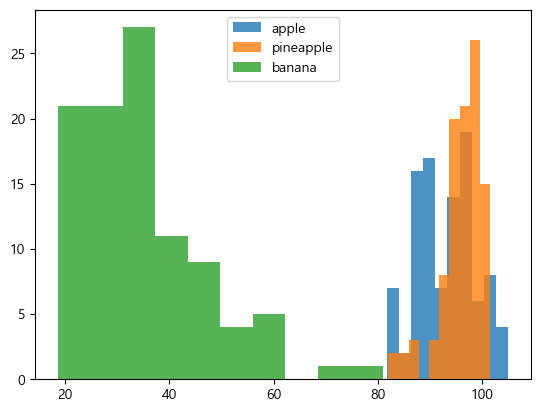

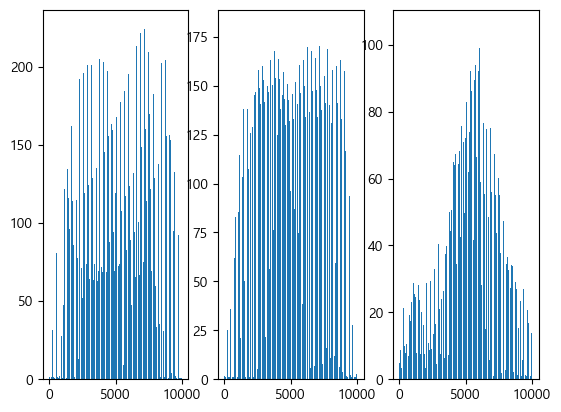

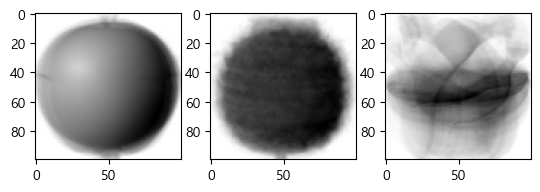

In [69]:
#픽셀값 분석을 위해 100x100이미지를 1x10000의 1차원으로 바꿈(reshape)
apple = fruits[0:100].reshape(-1, 100*100) #fruits[]의 0~99번째 이미지까지임. 열은 10000, 행은 자동 계산
pineapple = fruits[100:200].reshape(-1, 100*100)
banana = fruits[200:300].reshape(-1, 100*100)
print(apple.shape)
print(type(apple))
#픽셀의 평균값 계산(이미지의 평균 밝기)
plt.hist(apple.mean(axis=1), alpha=0.8, label='apple') #axis=0은 행을 따라 (세로)계산, axis=1은 열을 따라 (가로)계산
plt.hist(pineapple.mean(axis=1), alpha=0.8, label='pineapple')
plt.hist(banana.mean(axis=1), alpha=0.8, label='banana')
plt.legend()
plt.show()

#픽셀별 평균값(1x10000의 결과로 나타남)
fig, axs = plt.subplots(1,3)
axs[0].bar(range(10000), apple.mean(axis=0))
axs[1].bar(range(10000), pineapple.mean(axis=0))
axs[2].bar(range(10000), banana.mean(axis=0))
plt.show()

#픽셀별 평균값을 이미지로 나타내기
fig, axs = plt.subplots(1,3)
apple_mean = apple.mean(axis=0).reshape(100, 100)
pineapple_mean = pineapple.mean(axis=0).reshape(100, 100)
banana_mean = banana.mean(axis=0).reshape(100, 100)
axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap="gray_r")
plt.show()

(300, 100, 100)
(100, 100)
(300, 100, 100)
(300,)


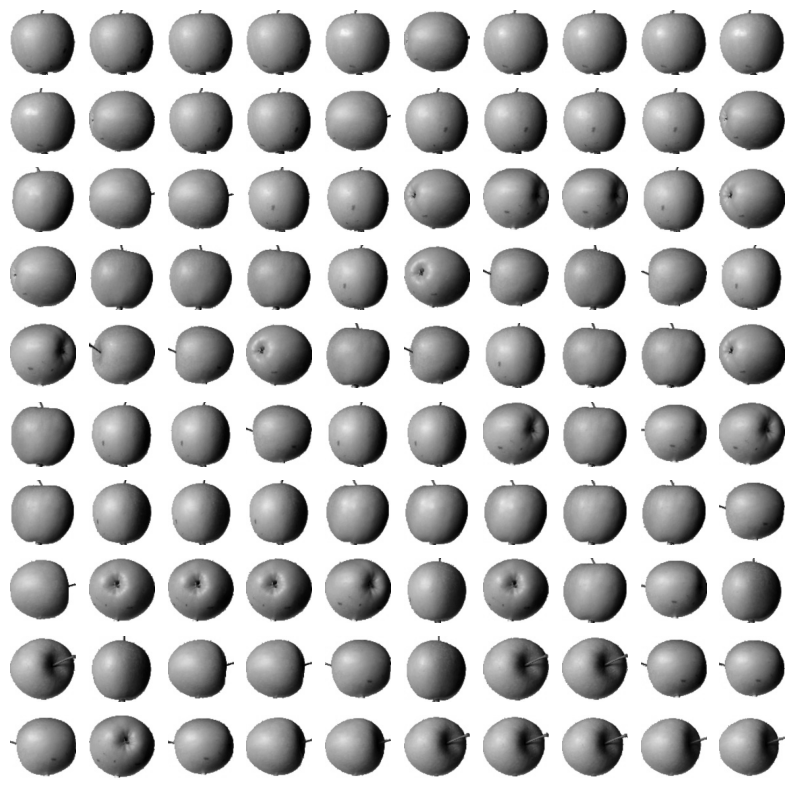

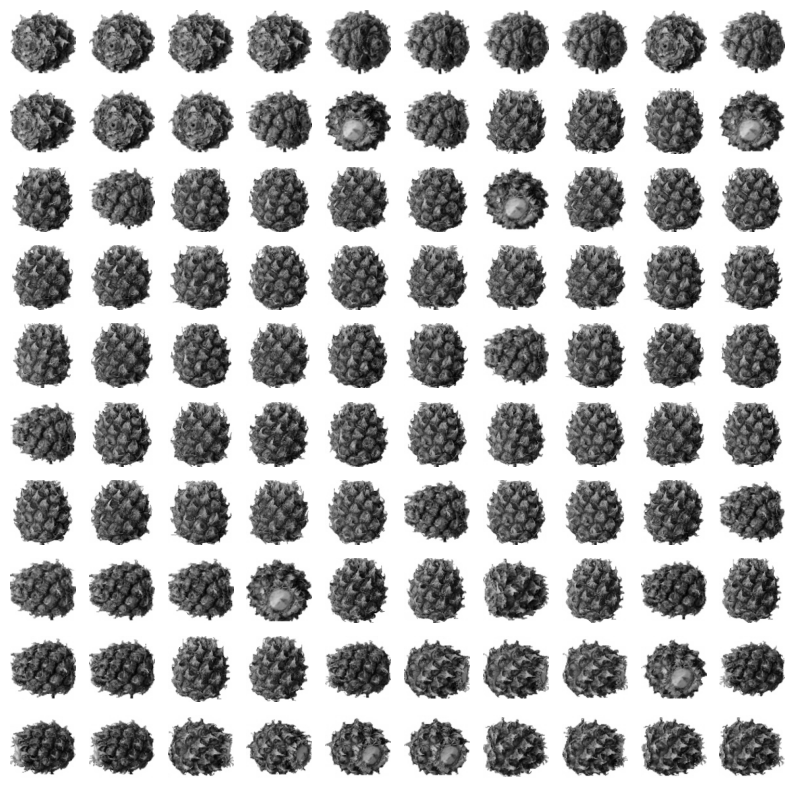

In [83]:
#전체 샘플의 각 이미지와 평균 밝기 이미지 간의 밝기 차이(절대오차)의 평균값 계산
abs_diff = np.abs(fruits - apple_mean)
abs_mean = np.mean(abs_diff, axis=(1, 2))
print(fruits.shape)
print(apple_mean.shape)
print(abs_diff.shape)
print(abs_mean.shape)

#오차 이미지의 평균 밝기가 작은 순서대로 100개를 선택함
apple_index = np.argsort(abs_mean) #abs_mean 배열에서 오름차순으로 정렬했을 때의 인덱스를 반환함
apple_index1 = apple_index[0:100].reshape(10,10)
fig, axs = plt.subplots(10, 10, figsize=(10,10)) #figsize는 전체 그림판의 (가로, 세로)크기를 지정하며 단위는 인치임
for i in range(10):
    for j in range(10):
        axs[i,j].imshow(fruits[apple_index1[i,j]], cmap='gray_r')
        axs[i,j].axis('off')
plt.show()

apple_index2 = apple_index[100:200].reshape(10,10)
fig, axs = plt.subplots(10, 10, figsize=(10,10)) #figsize는 전체 그림판의 (가로, 세로)크기를 지정하며 단위는 인치임
for i in range(10):
    for j in range(10):
        axs[i,j].imshow(fruits[apple_index2[i,j]], cmap='gray_r')
        axs[i,j].axis('off')
plt.show()

##### (2) k-평균 알고리즘
* 넘파이 배열 가져오기(터미널에서 시행): curl https://bit.ly/fruits_300_data -o fruits_300.npy

(300, 100, 100)
(300, 10000)
[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]
(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


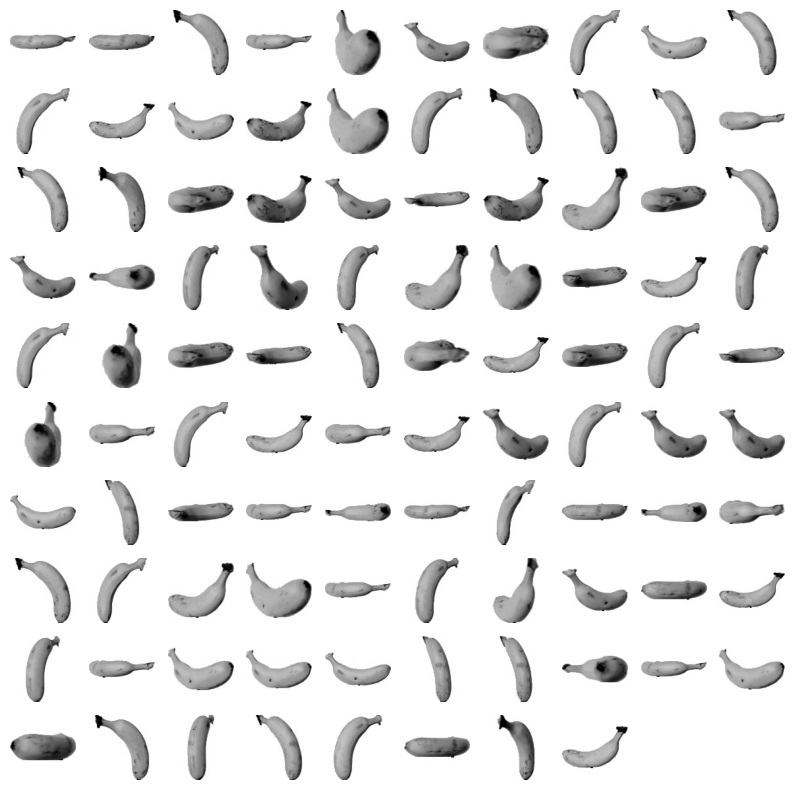

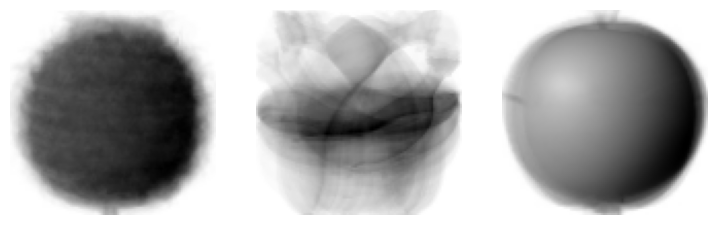

[[3400.24197319 8837.37750892 5279.33763699]]
[0]


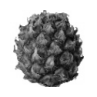

4


In [106]:
import numpy as np
fruits = np.load('fruits_300.npy')
print(fruits.shape) #(300, 100, 100)

#fruits를 (300, 10000)으로 변환
fruits_2d = fruits.reshape(-1, 100*100)
print(fruits_2d.shape) # KMeans의 fit()은 2차원 배열만 사용하도록 설계되어 있음

from sklearn.cluster import KMeans
km = KMeans(n_clusters = 3, random_state=42) 
km.fit(fruits_2d)
print(km.labels_)

#labels_별로 빈도를 출력
print(np.unique(km.labels_, return_counts=True))

#각 labels_값에 대한 이미지를 출력하는 함수를 만듦
def draw_fruits(arr, ratio=1): #ratio는 figsize 지정(rows, cols 수만큼 인치 단위로 지정)
    n = len(arr)
    rows = int(np.ceil(n/10))
    cols = n if rows <2 else 10 #rows가 1줄이면 개수 n이 cols값이 되며, 2줄 이상이면 cols는 최대값이 10이 됨
    fig, axs = plt.subplots(rows, cols, figsize=(cols*ratio, rows*ratio), squeeze=False) #squeeze가 False이면, axs[0,0]처럼 2차원 배열로 지정해야 함
    for i in range(rows):
        for j in range(cols):
            if i*10+j<n: #마지막 행은 열이 비어 있을 수 있음
                axs[i,j].imshow(arr[i*10+j], cmap='gray_r')
            axs[i,j].axis('off')
    plt.show()

draw_fruits(fruits[km.labels_==1]) #KMeans로 분류한 클러스터 중 0번 클러스터를 불리언 인덱싱으로 추출

#클러스터의 중심 출력: cluster_centers_ 속성에 저장되어 있음
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3)

#fruits_2d 배열(300, 10000)에서 인덱스가 100인 샘플에서 각 클러스터 중심까지의 거리 계산
print(km.transform(fruits_2d[100:101])) #fruits_2d[100]로 입력하면 1차원 배열이 되어 오류가 발생함

#100번째 샘플에 대한 예측 클래스 출력
print(km.predict(fruits_2d[100:101]))
draw_fruits(fruits[100:101])

#k-평균 알고리즘이 최적의 클러스터를 찾을 때까지 반복한 횟수 출력(n_iter_ 속성)
print(km.n_iter_)

* 최적의 k(클러스터 개수) 구하기
    - 이너셔 그래프에서 꺾인 지점을 기준으로 찾는 엘보우 방법 사용

c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: User

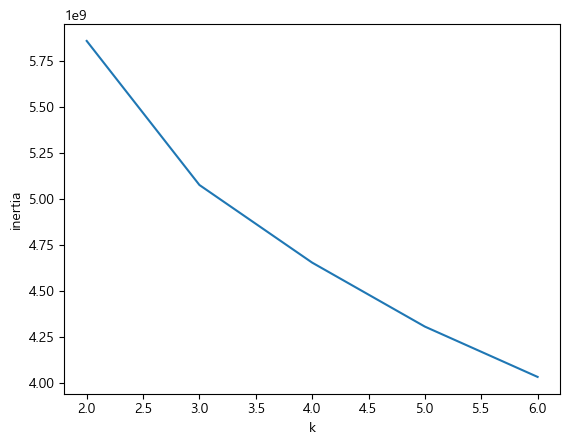

In [107]:
inertia = []
for k in range(2,7):
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)#n_init은 초기 중심점 설정을 위한 매개변수
    km.fit(fruits_2d)
    inertia.append(km.inertia_)
plt.plot(range(2,7), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

##### (3) 주성분 분석(PCA)
* 차원 축소
* PCA

In [109]:
import numpy as np
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

#PCA 모듈 임포트
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca.fit(fruits_2d)

#찾은 주성분 배열의 shape출력
print(pca.components_.shape)

(50, 10000)


* 셀을 마크다운으로 전환하는 단축키는 M
* 셀을 코드로 전환하는 단축키는 Y
* A는 바로 위에 셀을 만듦
* B는 바로 아래에 셀을 만듦
* Shift+Enter: 코드 실행 후 다음 셀로 이동
* Ctrl+Enter: 현재 셀의 코드 실행 후, 그대로 머뭄